# BTCUSDT Multi-Timeframe Data Quality + Model Readiness Audit

This notebook provides a full pre-model audit for deep learning forecasting (LSTM, TFT, Transformers) using your processed crypto dataset.

Coverage:
- Data quality (missing, gaps, outliers, distributions, stationarity, noise ratio, redundancy)
- Feature quality and leakage risk by feature group
- Label quality and class imbalance
- Multi-timeframe consistency (15m, 1H, 4H, 1D)
- Signal strength and predictability
- Model readiness score and practical performance expectations
- Prioritized improvement roadmap and final production verdict

In [1]:
from pathlib import Path
import sys
import warnings
from typing import Dict

import importlib.util
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import text

warnings.filterwarnings("ignore")

# Optional: statistical tests if available
adfuller = None
kpss = None
HAS_STATSMODELS = importlib.util.find_spec("statsmodels") is not None
if HAS_STATSMODELS:
    stattools = __import__("statsmodels.tsa.stattools", fromlist=["adfuller", "kpss"])
    adfuller = getattr(stattools, "adfuller", None)
    kpss = getattr(stattools, "kpss", None)

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from app.config.database import engine

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")

In [2]:
# ----------------------
# CONFIG
# ----------------------
SYMBOL = "BTCUSDT"
TIMEFRAMES = ["15m", "1h", "4h", "1d"]
PRED_HORIZONS = [1, 3, 6, 12]
BASE_TF = "15m"

def normalize_interval_for_table(interval: str) -> str:
    if interval.endswith("M"):
        interval = f"{interval[:-1]}mo"
    return "".join(ch for ch in interval.lower() if ch.isalnum())

def processed_table_name(symbol: str, interval: str) -> str:
    safe_symbol = "".join(ch for ch in symbol.lower() if ch.isalnum())
    safe_interval = normalize_interval_for_table(interval)
    return f"{safe_symbol}_{safe_interval}_processed"

def timeframe_to_minutes(tf: str) -> int:
    unit = tf[-1].lower()
    num = int(tf[:-1])
    if unit == "m":
        return num
    if unit == "h":
        return num * 60
    if unit == "d":
        return num * 1440
    raise ValueError(f"Unsupported timeframe: {tf}")

In [3]:
def load_table_df(table_name: str) -> pd.DataFrame:
    q = text(f"SELECT * FROM {table_name} ORDER BY open_time")
    df = pd.read_sql(q, engine)
    if df.empty:
        return df

    if "open_time" in df.columns:
        df["open_time"] = pd.to_datetime(df["open_time"], errors="coerce")
    df = df.dropna(subset=["open_time"]).sort_values("open_time").reset_index(drop=True)

    # Coerce likely numeric columns
    for col in df.columns:
        if col in {"open_time", "close_time", "trend", "trend_category", "fill_source", "fill_method",
                   "chart_pattern_type", "chart_pattern_direction", "chart_pattern_key_points"}:
            continue
        if df[col].dtype == object:
            converted = pd.to_numeric(df[col], errors="coerce")
            non_na_ratio = converted.notna().mean()
            if non_na_ratio >= 0.7:
                df[col] = converted

    return df

data_by_tf: Dict[str, pd.DataFrame] = {}
table_map = {}

for tf in TIMEFRAMES:
    tbl = processed_table_name(SYMBOL, tf)
    table_map[tf] = tbl
    try:
        data_by_tf[tf] = load_table_df(tbl)
        print(f"{tf}: loaded {len(data_by_tf[tf]):,} rows from {tbl}")
    except Exception as e:
        print(f"{tf}: failed to load {tbl} -> {e}")
        data_by_tf[tf] = pd.DataFrame()

available_tfs = [tf for tf, d in data_by_tf.items() if not d.empty]
if not available_tfs:
    raise ValueError("No timeframe data loaded. Check DB and table names.")

overview = pd.DataFrame({
    "timeframe": available_tfs,
    "rows": [len(data_by_tf[tf]) for tf in available_tfs],
    "columns": [len(data_by_tf[tf].columns) for tf in available_tfs],
    "start": [data_by_tf[tf]["open_time"].min() for tf in available_tfs],
    "end": [data_by_tf[tf]["open_time"].max() for tf in available_tfs],
})
overview

15m: loaded 302,031 rows from btcusdt_15m_processed
1h: loaded 75,508 rows from btcusdt_1h_processed
4h: loaded 18,877 rows from btcusdt_4h_processed
1d: loaded 3,147 rows from btcusdt_1d_processed


,timeframe,rows,columns,start,end
0,15m,302031,60,2017-08-17 04:00:00,2026-03-29 07:30:00
1,1h,75508,60,2017-08-17 04:00:00,2026-03-29 07:00:00
2,4h,18877,60,2017-08-17 04:00:00,2026-03-29 04:00:00
3,1d,3147,60,2017-08-17 00:00:00,2026-03-29 00:00:00


## 1) Data Quality Analysis

In [4]:
def detect_gaps(df: pd.DataFrame, tf: str) -> pd.DataFrame:
    d = df[["open_time"]].copy().sort_values("open_time")
    d["delta_min"] = d["open_time"].diff().dt.total_seconds() / 60.0
    expected = timeframe_to_minutes(tf)
    d["missing_bars"] = ((d["delta_min"] / expected).round() - 1).clip(lower=0).fillna(0).astype(int)
    return d[d["missing_bars"] > 0]

def robust_outlier_pct(s: pd.Series, threshold: float = 6.0) -> float:
    x = pd.to_numeric(s, errors="coerce").dropna()
    if len(x) < 30:
        return np.nan
    med = x.median()
    mad = (x - med).abs().median()
    if mad <= 1e-12:
        return 0.0
    z = 0.6745 * (x - med) / mad
    return float((z.abs() > threshold).mean() * 100)

quality_rows = []
missing_rows = []
outlier_rows = []
distribution_rows = []
gap_rows = []

for tf, df in data_by_tf.items():
    if df.empty:
        continue

    n = len(df)
    miss_pct = df.isna().mean() * 100
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

    gaps = detect_gaps(df, tf)
    total_missing_bars = int(gaps["missing_bars"].sum()) if not gaps.empty else 0

    quality_rows.append({
        "timeframe": tf,
        "rows": n,
        "avg_missing_pct": float(miss_pct.mean()),
        "max_missing_col_pct": float(miss_pct.max()),
        "gap_events": int(len(gaps)),
        "missing_bars_est": total_missing_bars,
    })

    for col, pct in miss_pct.sort_values(ascending=False).head(20).items():
        missing_rows.append({
            "timeframe": tf,
            "feature": col,
            "missing_pct": float(pct),
        })

    for col in numeric_cols:
        outlier_rows.append({
            "timeframe": tf,
            "feature": col,
            "outlier_pct": robust_outlier_pct(df[col]),
        })

    sample_numeric = numeric_cols[:40]
    for col in sample_numeric:
        x = pd.to_numeric(df[col], errors="coerce")
        distribution_rows.append({
            "timeframe": tf,
            "feature": col,
            "mean": float(x.mean()) if x.notna().any() else np.nan,
            "std": float(x.std()) if x.notna().any() else np.nan,
            "skew": float(x.skew()) if x.notna().any() else np.nan,
            "kurtosis": float(x.kurtosis()) if x.notna().any() else np.nan,
        })

    if not gaps.empty:
        g2 = gaps.copy()
        g2["timeframe"] = tf
        gap_rows.append(g2[["timeframe", "open_time", "delta_min", "missing_bars"]])

quality_summary = pd.DataFrame(quality_rows).sort_values("timeframe")
missing_summary = pd.DataFrame(missing_rows).sort_values(["timeframe", "missing_pct"], ascending=[True, False])
outlier_summary = pd.DataFrame(outlier_rows).sort_values(["timeframe", "outlier_pct"], ascending=[True, False])
distribution_summary = pd.DataFrame(distribution_rows)
gap_detail = pd.concat(gap_rows, ignore_index=True) if gap_rows else pd.DataFrame(columns=["timeframe", "open_time", "delta_min", "missing_bars"])

print("Quality overview")
display(quality_summary)
print("Top missing columns")
display(missing_summary.head(30))
print("Top outlier-heavy numeric features")
display(outlier_summary.head(30))

Quality overview


,timeframe,rows,avg_missing_pct,max_missing_col_pct,gap_events,missing_bars_est
0,15m,302031,6.479627,99.988412,33,385
3,1d,3147,6.382269,100.000000,0,0
1,1h,75508,6.686069,99.994703,28,81
2,4h,18877,6.654659,99.994703,8,8


Top missing columns


,timeframe,feature,missing_pct
0,15m,candle_pattern_complex,99.988412
1,15m,candle_pattern_3,99.950998
2,15m,candle_pattern_1,98.882896
3,15m,candle_pattern_2,82.542852
4,15m,chart_pattern_confidence,1.107171
5,15m,chart_pattern_direction,1.105847
6,15m,chart_pattern_type,1.105847
7,15m,chart_pattern_key_points,1.105847
8,15m,chart_pattern_start_time_ms,1.105847
9,15m,chart_pattern_end_time_ms,1.105847


Top outlier-heavy numeric features


,timeframe,feature,outlier_pct
17,15m,macd,6.095732
5,15m,volume,6.034149
18,15m,macd_signal,5.988127
8,15m,taker_buy_base_asset_volume,5.851386
19,15m,macd_hist,5.085571
7,15m,number_of_trades,4.920356
9,15m,taker_buy_quote_asset_volume,4.495234
6,15m,quote_asset_volume,4.042962
29,15m,vix,1.693955
28,15m,atr_14,0.529085


In [5]:
# Stationarity, noise-to-signal ratio, and redundancy
stationarity_rows = []
noise_rows = []
corr_rows = []

for tf, df in data_by_tf.items():
    if df.empty:
        continue

    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    candidate_cols = [c for c in ["close", "volume", "rsi_14", "macd", "adx_14", "atr_14", "turning_point_score"] if c in df.columns]

    # Stationarity tests (if statsmodels available)
    for col in candidate_cols:
        x = pd.to_numeric(df[col], errors="coerce").dropna()
        if len(x) < 100:
            continue

        adf_p = np.nan
        kpss_p = np.nan
        if HAS_STATSMODELS:
            try:
                adf_p = float(adfuller(x.values, autolag="AIC")[1])
            except Exception:
                pass
            try:
                kpss_p = float(kpss(x.values, regression="c", nlags="auto")[1])
            except Exception:
                pass

        stationarity_rows.append({
            "timeframe": tf,
            "feature": col,
            "adf_p_value": adf_p,
            "kpss_p_value": kpss_p,
            "likely_stationary": bool((adf_p < 0.05) if np.isfinite(adf_p) else False),
        })

    # Noise ratio and persistence for close
    if "close" in df.columns:
        close = pd.to_numeric(df["close"], errors="coerce")
        ret = close.pct_change()
        price_noise = float(close.diff().std() / max(1e-9, close.std()))
        ret_vol = float(ret.std())
        ret_autocorr_1 = float(ret.autocorr(lag=1)) if ret.notna().sum() > 10 else np.nan
        trend_strength = float((close.rolling(20).mean().diff().abs().mean()) / max(1e-9, close.diff().abs().mean()))

        noise_rows.append({
            "timeframe": tf,
            "price_noise_ratio": price_noise,
            "return_volatility": ret_vol,
            "return_autocorr_lag1": ret_autocorr_1,
            "trend_signal_ratio": trend_strength,
        })

    # Highly correlated feature pairs
    corr_candidates = [c for c in numeric_cols if pd.to_numeric(df[c], errors="coerce").notna().mean() > 0.8]
    corr_candidates = corr_candidates[:120]
    if len(corr_candidates) >= 2:
        corr = df[corr_candidates].corr(numeric_only=True).abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        stacked = upper.stack().reset_index()
        stacked.columns = ["f1", "f2", "abs_corr"]
        high_pairs = stacked[stacked["abs_corr"] >= 0.95].copy()
        if not high_pairs.empty:
            high_pairs["timeframe"] = tf
            corr_rows.append(high_pairs[["timeframe", "f1", "f2", "abs_corr"]])

stationarity_summary = pd.DataFrame(stationarity_rows)
noise_summary = pd.DataFrame(noise_rows).sort_values("timeframe")
high_corr_pairs = pd.concat(corr_rows, ignore_index=True) if corr_rows else pd.DataFrame(columns=["timeframe", "f1", "f2", "abs_corr"])

print("Stationarity summary")
display(stationarity_summary.head(40))
print("Noise vs signal summary")
display(noise_summary)
print("Highly correlated pairs (|corr| >= 0.95)")
display(high_corr_pairs.head(40))

Stationarity summary


,timeframe,feature,adf_p_value,kpss_p_value,likely_stationary
0,15m,close,NaN,NaN,False
1,15m,volume,NaN,NaN,False
2,15m,rsi_14,NaN,NaN,False
3,15m,macd,NaN,NaN,False
4,15m,adx_14,NaN,NaN,False
5,15m,atr_14,NaN,NaN,False
6,15m,turning_point_score,NaN,NaN,False
7,1h,close,NaN,NaN,False
8,1h,volume,NaN,NaN,False
9,1h,rsi_14,NaN,NaN,False


Noise vs signal summary


,timeframe,price_noise_ratio,return_volatility,return_autocorr_lag1,trend_signal_ratio
0,15m,0.004382,0.004075,-0.036017,0.221156
3,1d,0.040612,0.035677,-0.050919,0.241155
1,1h,0.008511,0.007825,-0.048713,0.238323
2,4h,0.016881,0.014806,-0.045916,0.244838


Highly correlated pairs (|corr| >= 0.95)


,timeframe,f1,f2,abs_corr
0,15m,id,open_time_ms,1.000000
1,15m,id,close_time_ms,1.000000
2,15m,id,ad_line,0.982812
3,15m,id,chart_pattern_start_time_ms,0.999998
4,15m,id,chart_pattern_end_time_ms,0.999998
5,15m,open,high,0.999994
6,15m,open,low,0.999993
7,15m,open,close,0.999991
8,15m,open,ma_20,0.999953
9,15m,open,ema_12,0.999984


## 2) Feature Quality Assessment

In [7]:
def feature_group(col: str) -> str:
    c = col.lower()
    if c in {"open", "high", "low", "close"}:
        return "price_based"
    if c in {"volume", "quote_asset_volume", "number_of_trades", "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume"} or any(k in c for k in ["obv", "vwap", "ad_line", "cmf", "volume_osc"]):
        return "volume_based"
    if c.startswith("candle_pattern") or c.startswith("chart_pattern"):
        return "pattern_based"
    if c in {"support", "resistance"}:
        return "structural"
    if c in {"trend", "trend_category", "is_turning_point", "turning_point_score"}:
        return "trend_labels"
    if any(k in c for k in ["rsi", "macd", "adx", "atr", "boll", "mfi", "ema", "sma", "stoch", "cci", "roc"]):
        return "indicator_based"
    return "other"

def safe_spearman_corr(a: pd.Series, b: pd.Series) -> float:
    frame = pd.DataFrame({"a": pd.to_numeric(a, errors="coerce"), "b": pd.to_numeric(b, errors="coerce")}).dropna()
    if len(frame) < 3:
        return np.nan
    # Spearman without scipy: Pearson correlation of ranks.
    return float(frame["a"].rank(method="average").corr(frame["b"].rank(method="average"), method="pearson"))

feature_quality_rows = []
weak_features = []

for tf, df in data_by_tf.items():
    if df.empty or "close" not in df.columns:
        continue

    future_ret = pd.to_numeric(df["close"], errors="coerce").pct_change().shift(-1)

    for col in df.columns:
        if col in {"id", "open_time", "close_time", "created_at", "updated_at"}:
            continue

        grp = feature_group(col)
        s = df[col]
        miss = float(s.isna().mean() * 100)
        n_unique = int(s.nunique(dropna=True))

        predictive_ic = np.nan
        lagging_score = np.nan

        if pd.api.types.is_numeric_dtype(s):
            x = pd.to_numeric(s, errors="coerce")
            predictive_ic = safe_spearman_corr(x, future_ret)

            now_ret = pd.to_numeric(df["close"], errors="coerce").pct_change()
            aligned_now = pd.DataFrame({"x": x, "r": now_ret}).dropna()
            aligned_future = pd.DataFrame({"x": x, "r": future_ret}).dropna()
            if len(aligned_now) >= 80 and len(aligned_future) >= 80:
                c_now = abs(float(aligned_now["x"].corr(aligned_now["r"])))
                c_fut = abs(float(aligned_future["x"].corr(aligned_future["r"])))
                lagging_score = c_now - c_fut

            variance = float(x.var(skipna=True))
            if miss > 60 or variance < 1e-10 or (np.isfinite(predictive_ic) and abs(predictive_ic) < 0.02):
                weak_features.append({
                    "timeframe": tf,
                    "feature": col,
                    "group": grp,
                    "missing_pct": miss,
                    "variance": variance,
                    "predictive_ic": predictive_ic,
                })

        feature_quality_rows.append({
            "timeframe": tf,
            "feature": col,
            "group": grp,
            "dtype": str(s.dtype),
            "missing_pct": miss,
            "n_unique": n_unique,
            "predictive_ic": predictive_ic,
            "lagging_score": lagging_score,
        })

feature_quality = pd.DataFrame(feature_quality_rows)
weak_feature_df = pd.DataFrame(weak_features).sort_values(["timeframe", "missing_pct"], ascending=[True, False]) if weak_features else pd.DataFrame()

group_quality = (
    feature_quality.groupby(["timeframe", "group"], as_index=False)
    .agg(
        n_features=("feature", "count"),
        avg_missing_pct=("missing_pct", "mean"),
        median_abs_predictive_ic=("predictive_ic", lambda x: float(np.nanmedian(np.abs(x)))),
        avg_lagging_score=("lagging_score", "mean"),
    )
    .sort_values(["timeframe", "median_abs_predictive_ic"], ascending=[True, False])
)

print("Feature-group quality summary")
display(group_quality)
print("Weak-feature candidates")
display(weak_feature_df.head(60) if not weak_feature_df.empty else weak_feature_df)

Feature-group quality summary


,timeframe,group,n_features,avg_missing_pct,median_abs_predictive_ic,avg_lagging_score
0,15m,indicator_based,15,0.026377,0.009050,0.083329
3,15m,price_based,4,0.044366,0.006925,-0.001647
4,15m,structural,2,0.038076,0.006523,-0.000546
1,15m,other,11,0.007495,0.006058,-0.000096
2,15m,pattern_based,10,38.800156,0.005737,0.000096
5,15m,trend_labels,4,0.000000,0.004666,-0.001190
6,15m,volume_based,9,0.004930,0.002855,0.010548
11,1d,structural,2,0.000000,0.040371,-0.004496
10,1d,price_based,4,0.000000,0.039382,-0.014940
8,1d,other,11,0.028888,0.026263,-0.004435


Weak-feature candidates


,timeframe,feature,group,missing_pct,variance,predictive_ic
34,15m,chart_pattern_confidence,pattern_based,1.107171,1.554639e-03,-0.001975
35,15m,chart_pattern_start_time_ms,pattern_based,1.105847,6.157150e+21,-0.005737
36,15m,chart_pattern_end_time_ms,pattern_based,1.105847,6.156269e+21,-0.005737
0,15m,open,price_based,0.044366,1.049671e+09,-0.006843
1,15m,high,price_based,0.044366,1.052725e+09,-0.006898
2,15m,low,price_based,0.044366,1.046547e+09,-0.006953
3,15m,close,price_based,0.044366,1.049671e+09,-0.007077
25,15m,vix,other,0.044366,2.336470e+01,0.008269
27,15m,vwap,volume_based,0.044366,5.988756e+07,-0.007712
16,15m,ma_20,other,0.038076,1.049602e+09,-0.006498


In [ ]:
def feature_group(col: str) -> str:
    c = col.lower()
    if c in {"open", "high", "low", "close"}:
        return "price_based"
    if c in {"volume", "quote_asset_volume", "number_of_trades", "taker_buy_base_asset_volume", "taker_buy_quote_asset_volume"} or any(k in c for k in ["obv", "vwap", "ad_line", "cmf", "volume_osc"]):
        return "volume_based"
    if c.startswith("candle_pattern") or c.startswith("chart_pattern"):
        return "pattern_based"
    if c in {"support", "resistance"}:
        return "structural"
    if c in {"trend", "trend_category", "is_turning_point", "turning_point_score"}:
        return "trend_labels"
    if any(k in c for k in ["rsi", "macd", "adx", "atr", "boll", "mfi", "ema", "sma", "stoch", "cci", "roc"]):
        return "indicator_based"
    return "other"

def safe_spearman_corr(a: pd.Series, b: pd.Series) -> float:
    frame = pd.DataFrame({"a": pd.to_numeric(a, errors="coerce"), "b": pd.to_numeric(b, errors="coerce")}).dropna()
    if len(frame) < 3:
        return np.nan
    # Spearman without scipy: Pearson correlation of ranks.
    return float(frame["a"].rank(method="average").corr(frame["b"].rank(method="average"), method="pearson"))

feature_quality_rows = []
weak_features = []

for tf, df in data_by_tf.items():
    if df.empty or "close" not in df.columns:
        continue

    future_ret = pd.to_numeric(df["close"], errors="coerce").pct_change().shift(-1)

    for col in df.columns:
        if col in {"id", "open_time", "close_time", "created_at", "updated_at"}:
            continue

        grp = feature_group(col)
        s = df[col]
        miss = float(s.isna().mean() * 100)
        n_unique = int(s.nunique(dropna=True))

        predictive_ic = np.nan
        lagging_score = np.nan

        if pd.api.types.is_numeric_dtype(s):
            x = pd.to_numeric(s, errors="coerce")
            predictive_ic = safe_spearman_corr(x, future_ret)

            now_ret = pd.to_numeric(df["close"], errors="coerce").pct_change()
            aligned_now = pd.DataFrame({"x": x, "r": now_ret}).dropna()
            aligned_future = pd.DataFrame({"x": x, "r": future_ret}).dropna()
            if len(aligned_now) >= 80 and len(aligned_future) >= 80:
                c_now = abs(float(aligned_now["x"].corr(aligned_now["r"])))
                c_fut = abs(float(aligned_future["x"].corr(aligned_future["r"])))
                lagging_score = c_now - c_fut

            variance = float(x.var(skipna=True))
            if miss > 60 or variance < 1e-10 or (np.isfinite(predictive_ic) and abs(predictive_ic) < 0.02):
                weak_features.append({
                    "timeframe": tf,
                    "feature": col,
                    "group": grp,
                    "missing_pct": miss,
                    "variance": variance,
                    "predictive_ic": predictive_ic,
                })

        feature_quality_rows.append({
            "timeframe": tf,
            "feature": col,
            "group": grp,
            "dtype": str(s.dtype),
            "missing_pct": miss,
            "n_unique": n_unique,
            "predictive_ic": predictive_ic,
            "lagging_score": lagging_score,
        })

feature_quality = pd.DataFrame(feature_quality_rows)
weak_feature_df = pd.DataFrame(weak_features).sort_values(["timeframe", "missing_pct"], ascending=[True, False]) if weak_features else pd.DataFrame()

group_quality = (
    feature_quality.groupby(["timeframe", "group"], as_index=False)
    .agg(
        n_features=("feature", "count"),
        avg_missing_pct=("missing_pct", "mean"),
        median_abs_predictive_ic=("predictive_ic", lambda x: float(np.nanmedian(np.abs(x)))),
        avg_lagging_score=("lagging_score", "mean"),
    )
    .sort_values(["timeframe", "median_abs_predictive_ic"], ascending=[True, False])
)

print("Feature-group quality summary")
display(group_quality)
print("Weak-feature candidates")
display(weak_feature_df.head(60) if not weak_feature_df.empty else weak_feature_df)

Feature-group quality summary


,timeframe,group,n_features,avg_missing_pct,median_abs_predictive_ic,avg_lagging_score
0,15m,indicator_based,15,0.026377,0.009050,0.083329
3,15m,price_based,4,0.044366,0.006925,-0.001647
4,15m,structural,2,0.038076,0.006523,-0.000546
1,15m,other,11,0.007495,0.006058,-0.000096
2,15m,pattern_based,10,38.800156,0.005737,0.000096
5,15m,trend_labels,4,0.000000,0.004666,-0.001190
6,15m,volume_based,9,0.004930,0.002855,0.010548
11,1d,structural,2,0.000000,0.040371,-0.004496
10,1d,price_based,4,0.000000,0.039382,-0.014940
8,1d,other,11,0.028888,0.026263,-0.004435


Weak-feature candidates


,timeframe,feature,group,missing_pct,variance,predictive_ic
34,15m,chart_pattern_confidence,pattern_based,1.107171,1.554639e-03,-0.001975
35,15m,chart_pattern_start_time_ms,pattern_based,1.105847,6.157150e+21,-0.005737
36,15m,chart_pattern_end_time_ms,pattern_based,1.105847,6.156269e+21,-0.005737
0,15m,open,price_based,0.044366,1.049671e+09,-0.006843
1,15m,high,price_based,0.044366,1.052725e+09,-0.006898
2,15m,low,price_based,0.044366,1.046547e+09,-0.006953
3,15m,close,price_based,0.044366,1.049671e+09,-0.007077
25,15m,vix,other,0.044366,2.336470e+01,0.008269
27,15m,vwap,volume_based,0.044366,5.988756e+07,-0.007712
16,15m,ma_20,other,0.038076,1.049602e+09,-0.006498


## 3) Data Leakage Detection

In [9]:
leakage_rules = [
    {
        "feature": "turning_point_score",
        "risk_level": "critical",
        "unsafe": True,
        "why_unsafe": "Computed with future highs/lows (shift(-1), shift(-2)) in turning_points.py.",
        "fix": "Do not use as model input. Recompute with only past windows or shift forward by 2+ bars.",
    },
    {
        "feature": "is_turning_point",
        "risk_level": "critical",
        "unsafe": True,
        "why_unsafe": "Pivot definition checks future candles; impossible in live prediction.",
        "fix": "Treat as target label for retrospective analysis only; never as contemporaneous feature.",
    },
    {
        "feature": "chart_pattern_*",
        "risk_level": "high",
        "unsafe": True,
        "why_unsafe": "Patterns are mapped across full detected windows, so early bars can inherit a pattern only known after completion.",
        "fix": "Emit pattern only at confirmation bar (window end), or shift pattern features to first tradable bar after confirmation.",
    },
    {
        "feature": "trend / trend_category",
        "risk_level": "medium",
        "unsafe": False,
        "why_unsafe": "Uses current candle close/open + indicators. Safe only for next-bar prediction after candle close.",
        "fix": "If predicting before close, lag by 1 bar. If predicting after close, allowed.",
    },
    {
        "feature": "support / resistance",
        "risk_level": "low",
        "unsafe": False,
        "why_unsafe": "Rolling min/max over past+current candle; generally causal.",
        "fix": "For strict causality at bar open, use shift(1).",
    },
]

leakage_df = pd.DataFrame(leakage_rules)
leakage_df

,feature,risk_level,unsafe,why_unsafe,fix
0,turning_point_score,critical,True,"Computed with future highs/lows (shift(-1), sh...",Do not use as model input. Recompute with only...
1,is_turning_point,critical,True,Pivot definition checks future candles; imposs...,Treat as target label for retrospective analys...
2,chart_pattern_*,high,True,Patterns are mapped across full detected windo...,Emit pattern only at confirmation bar (window ...
3,trend / trend_category,medium,False,Uses current candle close/open + indicators. S...,"If predicting before close, lag by 1 bar. If p..."
4,support / resistance,low,False,Rolling min/max over past+current candle; gene...,"For strict causality at bar open, use shift(1)."


## 4) Class / Label Analysis

In [10]:
label_rows = []
trend_dist_rows = []
pattern_rows = []

for tf, df in data_by_tf.items():
    if df.empty:
        continue

    if "trend" in df.columns:
        tr = df["trend"].astype(str).fillna("unknown")
        vc = tr.value_counts(dropna=False)
        for k, v in vc.items():
            trend_dist_rows.append({"timeframe": tf, "trend": k, "count": int(v), "pct": float(v / len(df) * 100)})
        if len(vc) >= 2:
            imbalance = float(vc.max() / max(1, vc.min()))
        else:
            imbalance = np.inf
    else:
        imbalance = np.nan

    tp_rate = float(df["is_turning_point"].mean() * 100) if "is_turning_point" in df.columns else np.nan

    # Label noise proxy: rapid trend flips
    if "trend" in df.columns:
        flips = (df["trend"].astype(str) != df["trend"].astype(str).shift(1)).mean() * 100
    else:
        flips = np.nan

    label_rows.append({
        "timeframe": tf,
        "trend_imbalance_ratio": imbalance,
        "turning_point_rate_pct": tp_rate,
        "trend_flip_rate_pct": float(flips) if np.isfinite(flips) else np.nan,
    })

    pat_cols = [c for c in df.columns if c.startswith("candle_pattern") or c == "chart_pattern_type"]
    for c in pat_cols:
        vc = df[c].astype("string").dropna().value_counts().head(10)
        for k, v in vc.items():
            pattern_rows.append({
                "timeframe": tf,
                "feature": c,
                "pattern": str(k),
                "count": int(v),
                "pct": float(v / len(df) * 100),
            })

label_summary = pd.DataFrame(label_rows).sort_values("timeframe")
trend_distribution = pd.DataFrame(trend_dist_rows).sort_values(["timeframe", "count"], ascending=[True, False])
pattern_distribution = pd.DataFrame(pattern_rows).sort_values(["timeframe", "count"], ascending=[True, False])

print("Label summary")
display(label_summary)
print("Trend class distribution")
display(trend_distribution.head(40))
print("Pattern occurrence distribution")
display(pattern_distribution.head(60))

Label summary


,timeframe,trend_imbalance_ratio,turning_point_rate_pct,trend_flip_rate_pct
0,15m,2.818490,28.235843,46.674017
3,1d,2.623100,26.342548,46.711153
1,1h,2.841623,28.353287,47.691635
2,4h,2.740538,28.155957,47.979022


Trend class distribution


,timeframe,trend,count,pct
0,15m,sideaway,172221,57.020968
1,15m,up,68706,22.747996
2,15m,down,61104,20.231036
9,1d,sideaway,1726,54.845885
10,1d,up,763,24.245313
11,1d,down,658,20.908802
3,1h,sideaway,42792,56.672141
4,1h,up,17657,23.384277
5,1h,down,15059,19.943582
6,4h,sideaway,10499,55.617948


Pattern occurrence distribution


,timeframe,feature,pattern,count,pct
14,15m,chart_pattern_type,Ascending Triangle,120992,40.059464
15,15m,chart_pattern_type,Descending Triangle,100746,33.356179
4,15m,candle_pattern_2,Bearish Engulfing,26431,8.751088
5,15m,candle_pattern_2,Bullish Engulfing,26257,8.693478
16,15m,chart_pattern_type,Triple Top,18485,6.120233
17,15m,chart_pattern_type,Triple Bottom,18098,5.992100
18,15m,chart_pattern_type,Double Bottom,17467,5.783181
19,15m,chart_pattern_type,Double Top,14433,4.778649
20,15m,chart_pattern_type,Head & Shoulders,4123,1.365092
21,15m,chart_pattern_type,Inverse Head & Shoulders,2887,0.955862


## 5) Multi-Timeframe Consistency

In [19]:
if BASE_TF not in data_by_tf or data_by_tf[BASE_TF].empty:
    raise ValueError(f"Base timeframe {BASE_TF} is required for alignment checks.")

base = data_by_tf[BASE_TF][["open_time", "close", "trend"]].copy()
base = base.sort_values("open_time")

mtf_rows = []
aligned_cache = {}

for tf in available_tfs:
    if tf == BASE_TF:
        continue
    h = data_by_tf[tf]
    if h.empty or "trend" not in h.columns:
        continue

    right = h[["open_time", "trend", "close"]].sort_values("open_time").rename(columns={"trend": f"trend_{tf}", "close": f"close_{tf}"})
    merged = pd.merge_asof(base.sort_values("open_time"), right, on="open_time", direction="backward")
    aligned_cache[tf] = merged

    valid = merged.dropna(subset=[f"trend_{tf}"])
    agree = (valid["trend"].astype(str) == valid[f"trend_{tf}"].astype(str)).mean() * 100 if len(valid) else np.nan
    sync_gap = (merged[f"trend_{tf}"].isna().mean()) * 100

    mtf_rows.append({
        "base_tf": BASE_TF,
        "higher_tf": tf,
        "trend_agreement_pct": float(agree) if np.isfinite(agree) else np.nan,
        "unmapped_pct": float(sync_gap),
        "rows_compared": int(len(valid)),
    })

mtf_consistency = pd.DataFrame(mtf_rows).sort_values("higher_tf")
mtf_consistency

,base_tf,higher_tf,trend_agreement_pct,unmapped_pct,rows_compared
2,15m,1d,46.105532,0.0,302031
0,15m,1h,57.878496,0.0,302031
1,15m,4h,49.856472,0.0,302031


## 6) Signal Strength Analysis

In [12]:
signal_rows = []

for tf, df in data_by_tf.items():
    if df.empty or "close" not in df.columns:
        continue

    work = df.copy()
    close = pd.to_numeric(work["close"], errors="coerce")

    for h in PRED_HORIZONS:
        work[f"fwd_ret_{h}"] = close.shift(-h) / close - 1.0

    # Turning-point signal strength
    if "is_turning_point" in work.columns:
        sig = work[work["is_turning_point"] == True]
        if len(sig) > 0:
            for h in PRED_HORIZONS:
                r = sig[f"fwd_ret_{h}"].dropna()
                if len(r) > 0:
                    signal_rows.append({
                        "timeframe": tf,
                        "signal_type": "turning_point",
                        "signal_name": "is_turning_point",
                        "horizon": h,
                        "samples": int(len(r)),
                        "avg_abs_move_pct": float((r.abs().mean()) * 100),
                        "snr": float(r.mean() / max(1e-12, r.std())),
                        "win_rate_pct": float((r > 0).mean() * 100),
                    })

    # Candlestick pattern strength
    pat_cols = [c for c in work.columns if c.startswith("candle_pattern")]
    if pat_cols:
        long_pat = work.reset_index().melt(
            id_vars=["index"] + [f"fwd_ret_{h}" for h in PRED_HORIZONS],
            value_vars=pat_cols,
            var_name="pattern_col",
            value_name="pattern",
        ).dropna(subset=["pattern"])

        pat_counts = long_pat["pattern"].value_counts()
        top_patterns = pat_counts[pat_counts >= 25].index.tolist()

        for p in top_patterns:
            sub = long_pat[long_pat["pattern"] == p]
            for h in PRED_HORIZONS:
                r = sub[f"fwd_ret_{h}"].dropna()
                if len(r) > 0:
                    signal_rows.append({
                        "timeframe": tf,
                        "signal_type": "candlestick_pattern",
                        "signal_name": str(p),
                        "horizon": h,
                        "samples": int(len(r)),
                        "avg_abs_move_pct": float((r.abs().mean()) * 100),
                        "snr": float(r.mean() / max(1e-12, r.std())),
                        "win_rate_pct": float((r > 0).mean() * 100),
                    })

    # Chart pattern strength
    if "chart_pattern_type" in work.columns:
        vc = work["chart_pattern_type"].astype("string").value_counts(dropna=True)
        top_chart = vc[vc >= 25].index.tolist()
        for p in top_chart:
            sub = work[work["chart_pattern_type"].astype("string") == p]
            for h in PRED_HORIZONS:
                r = sub[f"fwd_ret_{h}"].dropna()
                if len(r) > 0:
                    signal_rows.append({
                        "timeframe": tf,
                        "signal_type": "chart_pattern",
                        "signal_name": str(p),
                        "horizon": h,
                        "samples": int(len(r)),
                        "avg_abs_move_pct": float((r.abs().mean()) * 100),
                        "snr": float(r.mean() / max(1e-12, r.std())),
                        "win_rate_pct": float((r > 0).mean() * 100),
                    })

signal_strength = pd.DataFrame(signal_rows)
signal_strength_sorted = signal_strength.sort_values(["timeframe", "snr"], ascending=[True, False]) if not signal_strength.empty else signal_strength
signal_strength_sorted.head(80)

,timeframe,signal_type,signal_name,horizon,samples,avg_abs_move_pct,snr,win_rate_pct
43,15m,chart_pattern,Ascending Triangle,12,120944,0.764119,0.259590,62.413183
55,15m,chart_pattern,Triple Bottom,12,18098,0.576871,0.191516,57.315725
24,15m,candlestick_pattern,Shootingstar,1,114,0.450785,0.174031,55.263158
26,15m,candlestick_pattern,Shootingstar,6,114,1.212887,0.169676,65.789474
20,15m,candlestick_pattern,Invertedhammer,1,156,0.554688,0.164826,57.692308
...,...,...,...,...,...,...,...,...
34,15m,candlestick_pattern,Morningstar,6,57,1.169892,-0.349695,35.087719
219,1d,chart_pattern,Flag,12,704,13.348391,0.362073,67.187500
235,1d,chart_pattern,Symmetrical Triangle,12,41,13.101663,0.271244,73.170732
218,1d,chart_pattern,Flag,6,710,8.013210,0.265536,62.394366


## 7) Model Readiness Score

In [13]:
def clamp(v, lo=0, hi=100):
    return max(lo, min(hi, float(v)))

# Aggregate diagnostics for scoring
avg_missing = float(quality_summary["avg_missing_pct"].mean()) if not quality_summary.empty else 100.0
avg_gap = float(quality_summary["missing_bars_est"].mean()) if not quality_summary.empty else 9999.0
avg_outlier = float(outlier_summary["outlier_pct"].dropna().mean()) if not outlier_summary.empty else 100.0

weak_ratio = float(len(weak_feature_df) / max(1, len(feature_quality))) if not feature_quality.empty else 1.0
high_corr_ratio = float(len(high_corr_pairs) / max(1, len(feature_quality))) if not feature_quality.empty else 1.0

avg_trend_imbalance = float(label_summary["trend_imbalance_ratio"].replace([np.inf, -np.inf], np.nan).dropna().mean()) if not label_summary.empty else np.nan
avg_flip_rate = float(label_summary["trend_flip_rate_pct"].mean()) if not label_summary.empty else np.nan

critical_leak_count = int((leakage_df["risk_level"] == "critical").sum())
high_leak_count = int((leakage_df["risk_level"] == "high").sum())

# Scoring rules (brutally practical): leakage and label definition dominate readiness
data_quality_score = clamp(100 - (avg_missing * 1.4) - (avg_outlier * 1.2) - (np.log1p(avg_gap) * 6.0))
feature_quality_score = clamp(100 - (weak_ratio * 100 * 0.8) - (high_corr_ratio * 100 * 1.6))
label_quality_score = clamp(100 - (max(0, (avg_trend_imbalance - 1.5)) * 12) - ((avg_flip_rate if np.isfinite(avg_flip_rate) else 50) * 0.5) - (critical_leak_count * 20) - (high_leak_count * 12))

overall_ml_readiness = clamp(
    data_quality_score * 0.35 +
    feature_quality_score * 0.30 +
    label_quality_score * 0.35
)

readiness_scores = pd.DataFrame([
    {"component": "data_quality", "score_0_100": round(data_quality_score, 2)},
    {"component": "feature_quality", "score_0_100": round(feature_quality_score, 2)},
    {"component": "label_quality", "score_0_100": round(label_quality_score, 2)},
    {"component": "overall_ml_readiness", "score_0_100": round(overall_ml_readiness, 2)},
])

readiness_scores

,component,score_0_100
0,data_quality,61.17
1,feature_quality,0.00
2,label_quality,9.30
3,overall_ml_readiness,24.66


## 8) Expected Model Performance (Realistic)

In [14]:
def perf_band(base: float, boost: float = 0.0):
    center = base + boost
    lo = max(45.0, center - 3.5)
    hi = min(70.0, center + 3.5)
    return f"{lo:.1f}% - {hi:.1f}%"

# Directional accuracy expectation for next-bar sign prediction in live trading
# Assumption: leakage fixed before training.
readiness_factor = overall_ml_readiness / 100.0
base_acc = 49.5 + (readiness_factor * 7.0)

model_perf = pd.DataFrame([
    {
        "model": "XGBoost baseline",
        "expected_directional_accuracy": perf_band(base_acc, -0.8),
        "overfitting_risk": "medium",
        "generalization": "usually best first benchmark; stable with robust CV",
    },
    {
        "model": "LSTM",
        "expected_directional_accuracy": perf_band(base_acc, -0.2),
        "overfitting_risk": "medium-high",
        "generalization": "sensitive to regime shifts and sequence length tuning",
    },
    {
        "model": "TFT / Transformer",
        "expected_directional_accuracy": perf_band(base_acc, 0.2),
        "overfitting_risk": "high (if leakage, weak regularization, or poor splits)",
        "generalization": "can outperform in richer settings, but fails fast with noisy labels",
    },
])

model_perf

,model,expected_directional_accuracy,overfitting_risk,generalization
0,XGBoost baseline,46.9% - 53.9%,medium,usually best first benchmark; stable with robu...
1,LSTM,47.5% - 54.5%,medium-high,sensitive to regime shifts and sequence length...
2,TFT / Transformer,47.9% - 54.9%,"high (if leakage, weak regularization, or poor...","can outperform in richer settings, but fails f..."


## 9) Improvement Roadmap (Prioritized)

In [15]:
roadmap = pd.DataFrame([
    {
        "priority": "P0 - Critical",
        "action": "Remove leakage features from model inputs",
        "details": "Drop turning_point_score/is_turning_point as input; shift or re-engineer chart_pattern_* to confirmation-only timestamps.",
        "expected_impact": "Prevents fake backtest alpha; essential for live validity.",
    },
    {
        "priority": "P0 - Critical",
        "action": "Use strict walk-forward splits",
        "details": "Train/valid/test by time blocks, no random split, no overlap leakage in sequence windows.",
        "expected_impact": "Honest estimate of real-world performance.",
    },
    {
        "priority": "P1 - High",
        "action": "Re-label targets with tradable definitions",
        "details": "Use future return over N bars with volatility-adjusted thresholds and neutral class.",
        "expected_impact": "Lower label noise, better class separability.",
    },
    {
        "priority": "P1 - High",
        "action": "Prune redundant and weak features",
        "details": "Remove near-zero variance and ultra-correlated indicators; keep causal, orthogonal signals.",
        "expected_impact": "Improves generalization and training stability.",
    },
    {
        "priority": "P2 - Optional",
        "action": "Multi-timeframe feature fusion",
        "details": "Use 15m as base with lagged 1H/4H/1D context embeddings and mask-aware alignment.",
        "expected_impact": "Adds context; moderate gains if alignment is clean.",
    },
])

roadmap

,priority,action,details,expected_impact
0,P0 - Critical,Remove leakage features from model inputs,Drop turning_point_score/is_turning_point as i...,Prevents fake backtest alpha; essential for li...
1,P0 - Critical,Use strict walk-forward splits,"Train/valid/test by time blocks, no random spl...",Honest estimate of real-world performance.
2,P1 - High,Re-label targets with tradable definitions,Use future return over N bars with volatility-...,"Lower label noise, better class separability."
3,P1 - High,Prune redundant and weak features,Remove near-zero variance and ultra-correlated...,Improves generalization and training stability.
4,P2 - Optional,Multi-timeframe feature fusion,Use 15m as base with lagged 1H/4H/1D context e...,Adds context; moderate gains if alignment is c...


## 10) Final Verdict

In [16]:
critical_leakage = int((leakage_df["unsafe"] == True).sum())
realistic_ceiling = 55 + (overall_ml_readiness - 50) * 0.08
realistic_ceiling = float(max(50.0, min(62.0, realistic_ceiling)))

prod_ready = (overall_ml_readiness >= 75) and (critical_leakage == 0)
biggest_factor = "label leakage + noisy short-horizon labels" if critical_leakage > 0 else "non-stationarity and low signal-to-noise"

verdict = pd.DataFrame([
    {
        "question": "Is dataset sufficient for production-level prediction?",
        "answer": "Yes, with caution" if prod_ready else "Not yet",
    },
    {
        "question": "Realistic live directional accuracy ceiling",
        "answer": f"~{realistic_ceiling:.1f}% (before fees/slippage impact)",
    },
    {
        "question": "Biggest limiting factor",
        "answer": biggest_factor,
    },
])

verdict

,question,answer
0,Is dataset sufficient for production-level pre...,Not yet
1,Realistic live directional accuracy ceiling,~53.0% (before fees/slippage impact)
2,Biggest limiting factor,label leakage + noisy short-horizon labels


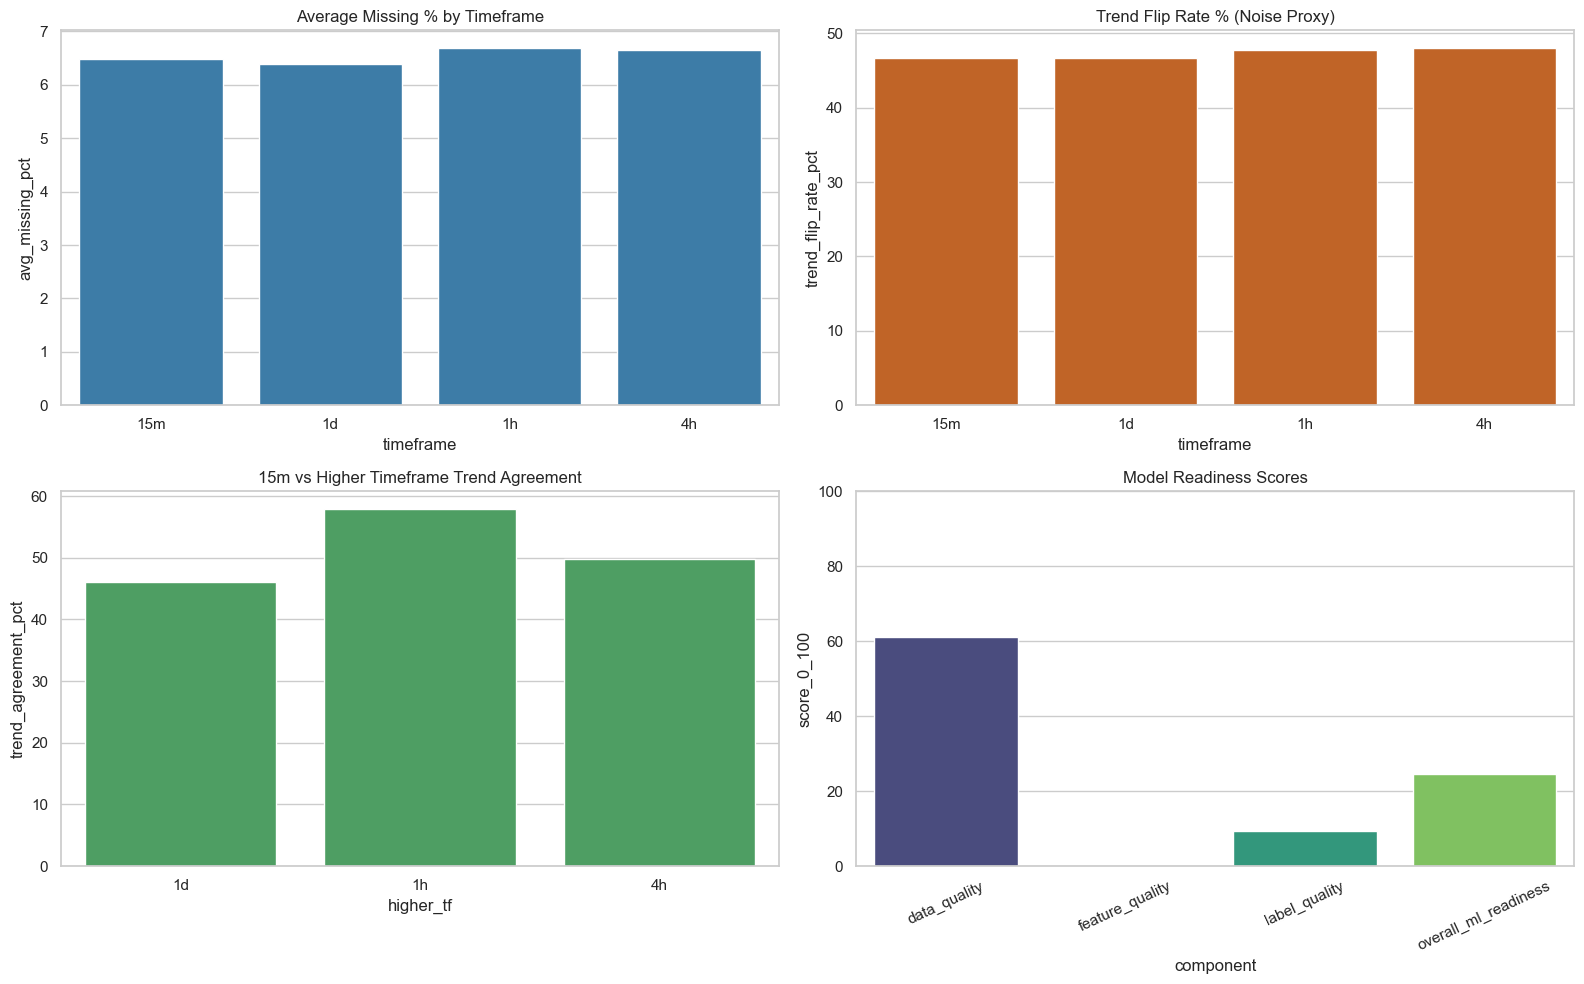

In [17]:
# Compact visualization dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if not quality_summary.empty:
    sns.barplot(data=quality_summary, x="timeframe", y="avg_missing_pct", ax=axes[0, 0], color="#2C7FB8")
    axes[0, 0].set_title("Average Missing % by Timeframe")

if not label_summary.empty:
    sns.barplot(data=label_summary, x="timeframe", y="trend_flip_rate_pct", ax=axes[0, 1], color="#D95F0E")
    axes[0, 1].set_title("Trend Flip Rate % (Noise Proxy)")

if not mtf_consistency.empty:
    sns.barplot(data=mtf_consistency, x="higher_tf", y="trend_agreement_pct", ax=axes[1, 0], color="#41AB5D")
    axes[1, 0].set_title(f"{BASE_TF} vs Higher Timeframe Trend Agreement")

sns.barplot(data=readiness_scores, x="component", y="score_0_100", ax=axes[1, 1], palette="viridis")
axes[1, 1].set_ylim(0, 100)
axes[1, 1].tick_params(axis="x", rotation=25)
axes[1, 1].set_title("Model Readiness Scores")

plt.tight_layout()
plt.show()

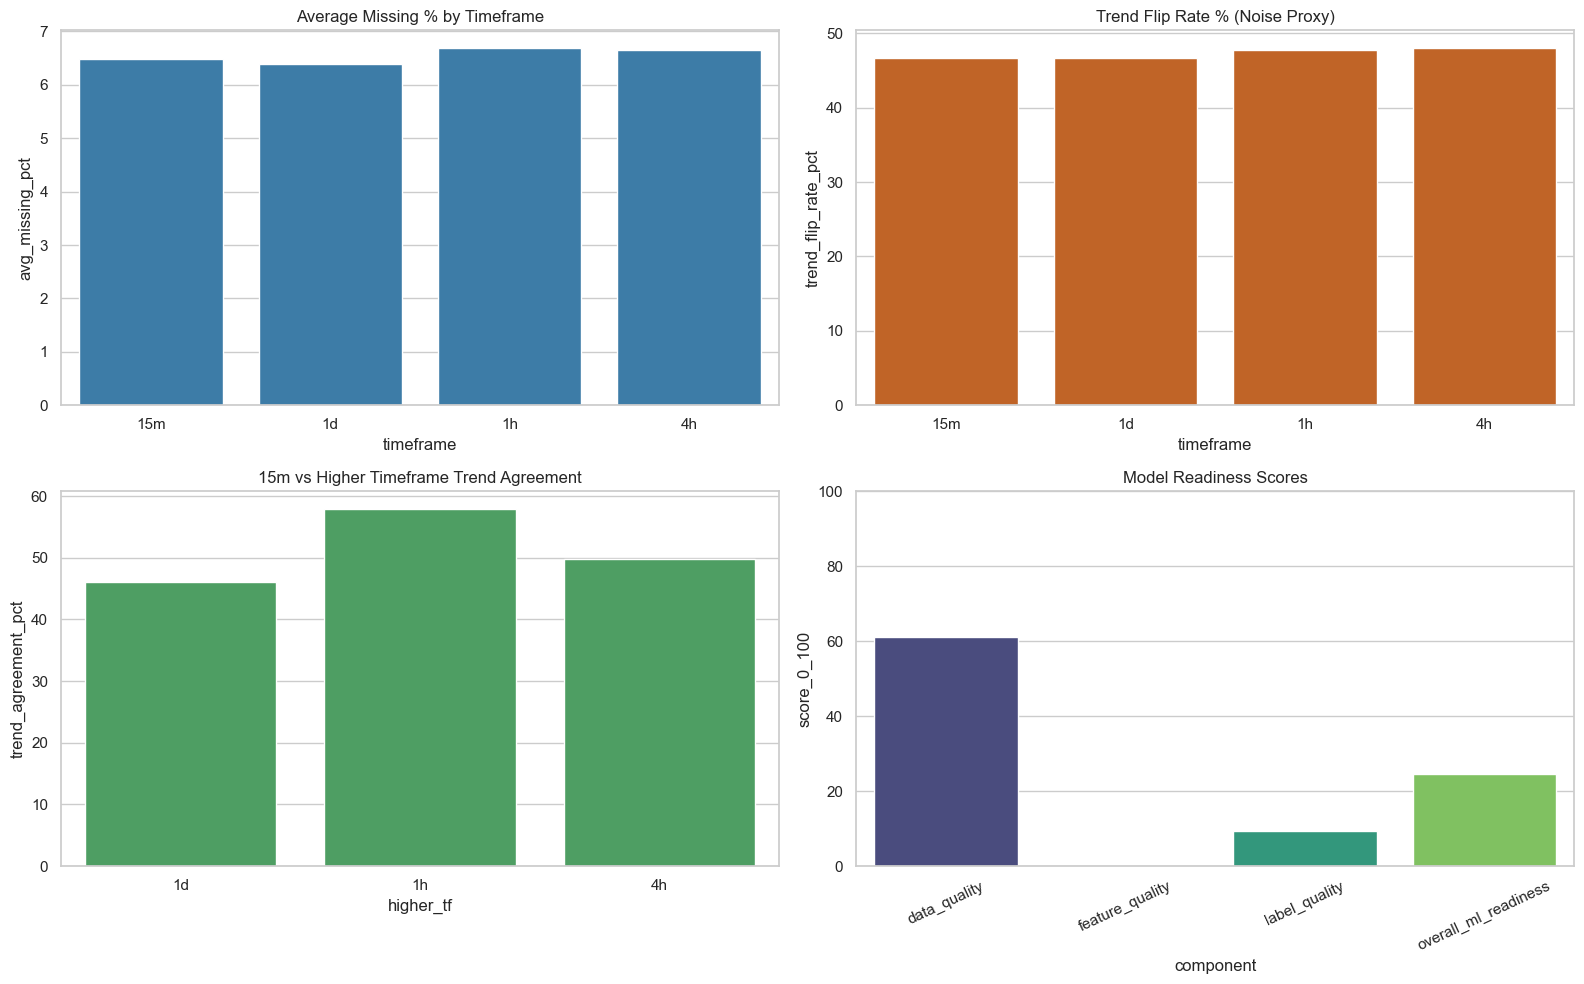

In [ ]:
# Compact visualization dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

if not quality_summary.empty:
    sns.barplot(data=quality_summary, x="timeframe", y="avg_missing_pct", ax=axes[0, 0], color="#2C7FB8")
    axes[0, 0].set_title("Average Missing % by Timeframe")

if not label_summary.empty:
    sns.barplot(data=label_summary, x="timeframe", y="trend_flip_rate_pct", ax=axes[0, 1], color="#D95F0E")
    axes[0, 1].set_title("Trend Flip Rate % (Noise Proxy)")

if not mtf_consistency.empty:
    sns.barplot(data=mtf_consistency, x="higher_tf", y="trend_agreement_pct", ax=axes[1, 0], color="#41AB5D")
    axes[1, 0].set_title(f"{BASE_TF} vs Higher Timeframe Trend Agreement")

sns.barplot(data=readiness_scores, x="component", y="score_0_100", ax=axes[1, 1], palette="viridis")
axes[1, 1].set_ylim(0, 100)
axes[1, 1].tick_params(axis="x", rotation=25)
axes[1, 1].set_title("Model Readiness Scores")

plt.tight_layout()
plt.show()